

### 1. library import


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import plotly.express as px

### 2. DATA SIMULASI (DUMMY DATA)

In [5]:
np.random.seed(42)

# Kasus Normal: Bawang merah tumbuh subur
suhu_normal = np.random.normal(28, 1.5, 200)
kelembapan_normal = np.random.normal(65, 5, 200)
nutrisi_normal = np.random.normal(1.5, 0.2, 200)

# Anomali 1: Pompa air mati (Kering)
suhu_kering = np.random.uniform(33, 38, 5)
kelembapan_kering = np.random.uniform(15, 25, 5)
nutrisi_kering = np.random.uniform(1.2, 1.6, 5)

# Anomali 2: Pipa air bocor (Banjir)
suhu_banjir = np.random.uniform(22, 26, 5)
kelembapan_banjir = np.random.uniform(85, 95, 5)
# TYPO DIPERBAIKI DI SINI:
nutrisi_banjir = np.random.uniform(0.5, 0.8, 5)

# Anomali 3: Katup Tandon Pupuk Jebol (Over-Fertilization)
suhu_pupuk = np.random.normal(28, 1.5, 5)
kelembapan_pupuk = np.random.normal(65, 5, 5)
nutrisi_pupuk = np.random.uniform(4.0, 5.0, 5)

# Menggabungkan data (SEMUA VARIABEL DIMASUKKAN)
suhu = np.concatenate([suhu_normal, suhu_kering, suhu_banjir, suhu_pupuk])
kelembapan = np.concatenate([kelembapan_normal, kelembapan_kering, kelembapan_banjir, kelembapan_pupuk])
nutrisi = np.concatenate([nutrisi_normal, nutrisi_kering, nutrisi_banjir, nutrisi_pupuk])

df_sensor = pd.DataFrame({'Suhu': suhu, 'Kelembapan': kelembapan, 'Kadar_Nutrisi': nutrisi})

### 2. TRAIN MODEL ISOLATION FOREST

In [6]:
model = IsolationForest(n_estimators=100, contamination=0.07, random_state=42)
model.fit(df_sensor)

# Prediksi: 1 (Normal) atau -1 (Anomali)
df_sensor['Status'] = model.predict(df_sensor)
df_sensor['Label'] = df_sensor['Status'].map({1: 'Normal', -1: 'Anomali'})

### 3. Visualisassi Result

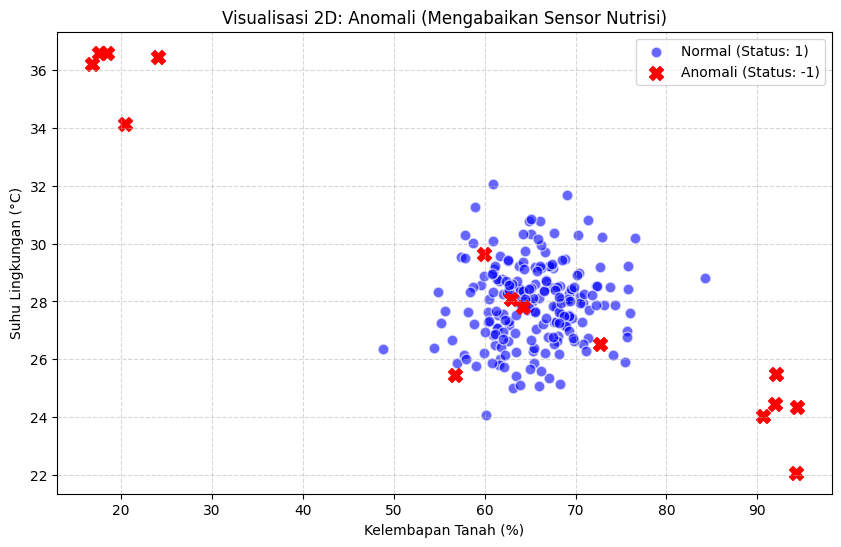


Coba perhatikan grafik 2D di atas! Ada anomali (X merah) yang letaknya membaur di tengah kerumunan biru. Ini adalah anomali 'Pupuk Jebol' yang tidak terlihat di 2D.



In [7]:
plt.figure(figsize=(10, 6))

normal_data = df_sensor[df_sensor['Status'] == 1]
anomali_data = df_sensor[df_sensor['Status'] == -1]

plt.scatter(normal_data['Kelembapan'], normal_data['Suhu'],
            c='blue', label='Normal (Status: 1)', alpha=0.6, edgecolors='w', s=60)
plt.scatter(anomali_data['Kelembapan'], anomali_data['Suhu'],
            c='red', label='Anomali (Status: -1)', marker='X', s=100)

plt.title('Visualisasi 2D: Anomali (Mengabaikan Sensor Nutrisi)')
plt.xlabel('Kelembapan Tanah (%)')
plt.ylabel('Suhu Lingkungan (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\nCoba perhatikan grafik 2D di atas! Ada anomali (X merah) yang letaknya membaur di tengah kerumunan biru. Ini adalah anomali 'Pupuk Jebol' yang tidak terlihat di 2D.\n")

### VISUALISASI 3 DIMENSI INTERAKTIF

In [8]:
fig = px.scatter_3d(df_sensor,
                    x='Kelembapan',
                    y='Suhu',
                    z='Kadar_Nutrisi',
                    color='Label',
                    color_discrete_map={'Normal': 'blue', 'Anomali': 'red'},
                    symbol='Label',
                    title='Visualisasi 3D: Anomali Terlihat Jelas dengan Sensor Nutrisi',
                    opacity=0.8)

fig.update_traces(marker=dict(size=5), selector=dict(name='Normal'))
fig.update_traces(marker=dict(size=8), selector=dict(name='Anomali'))

fig.show()

print("\n Log Data: Sensor Terdeteksi Anomali ")
# Tampilkan 15 data anomali agar terlihat semua
print(df_sensor[df_sensor['Status'] == -1].round(2))


 Log Data: Sensor Terdeteksi Anomali 
      Suhu  Kelembapan  Kadar_Nutrisi  Status    Label
200  34.15       20.43           1.43      -1  Anomali
201  36.61       17.52           1.36      -1  Anomali
202  36.60       18.46           1.38      -1  Anomali
203  36.21       16.82           1.58      -1  Anomali
204  36.47       24.08           1.26      -1  Anomali
205  24.34       94.32           0.55      -1  Anomali
206  24.02       90.65           0.67      -1  Anomali
207  24.45       91.97           0.68      -1  Anomali
208  22.07       94.22           0.63      -1  Anomali
209  25.49       92.07           0.72      -1  Anomali
210  26.52       72.65           4.54      -1  Anomali
211  27.81       64.21           4.92      -1  Anomali
212  28.08       62.87           4.35      -1  Anomali
213  29.64       59.94           4.35      -1  Anomali
214  25.46       56.73           4.74      -1  Anomali
